In [7]:
# Already in project root

Data shape: (9, 10)


,mask_ratio,epochs,final_loss,avg_loss,num_loss_values,training_time_sec,training_time_min,checkpoint,log_file,return_code
0,0.25,1,0.5920,0.806175,1000,33.000000,0.550000,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
1,0.25,5,0.5034,0.594381,9097,607.227781,10.120463,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
2,0.25,10,0.4583,0.524115,20000,1560.307635,26.005127,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
3,0.50,1,0.5943,0.818151,2000,167.622374,2.793706,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
4,0.50,5,0.6651,0.649077,10000,831.252083,13.854201,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
5,0.50,10,0.5224,0.572494,20000,1566.102202,26.101703,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
6,0.75,1,0.6225,0.849049,2000,166.901151,2.781686,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
7,0.75,5,0.7534,0.725249,10000,772.562207,12.876037,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0
8,0.75,10,0.6614,0.667173,20000,1531.467522,25.524459,/content/drive/MyDrive/CS543/group project/sim...,/content/drive/MyDrive/CS543/group project/sim...,0


,mask_ratio,epochs,final_loss,avg_loss,num_loss_values,training_time_min
0,0.25,1,0.5920,0.806175,1000,0.550000
1,0.25,5,0.5034,0.594381,9097,10.120463
2,0.25,10,0.4583,0.524115,20000,26.005127
3,0.50,1,0.5943,0.818151,2000,2.793706
4,0.50,5,0.6651,0.649077,10000,13.854201
5,0.50,10,0.5224,0.572494,20000,26.101703
6,0.75,1,0.6225,0.849049,2000,2.781686
7,0.75,5,0.7534,0.725249,10000,12.876037
8,0.75,10,0.6614,0.667173,20000,25.524459


Final loss table:


Epochs,1,5,10
Mask Ratio,,,
0.25,0.5920,0.5034,0.4583
0.50,0.5943,0.6651,0.5224
0.75,0.6225,0.7534,0.6614


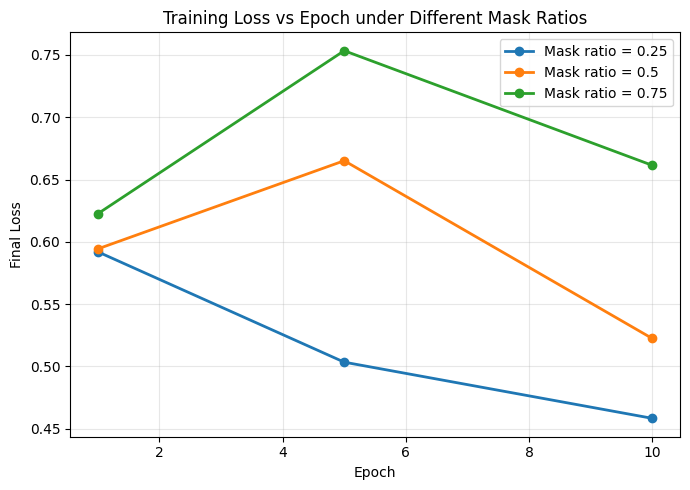

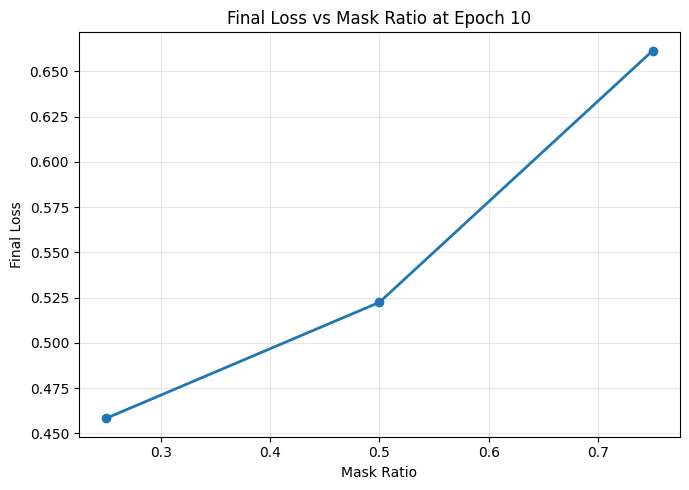

,mask_ratio,epochs,final_loss,avg_loss,num_loss_values,training_time_min
2,0.25,10,0.4583,0.524115,20000,26.005127
5,0.50,10,0.5224,0.572494,20000,26.101703
8,0.75,10,0.6614,0.667173,20000,25.524459


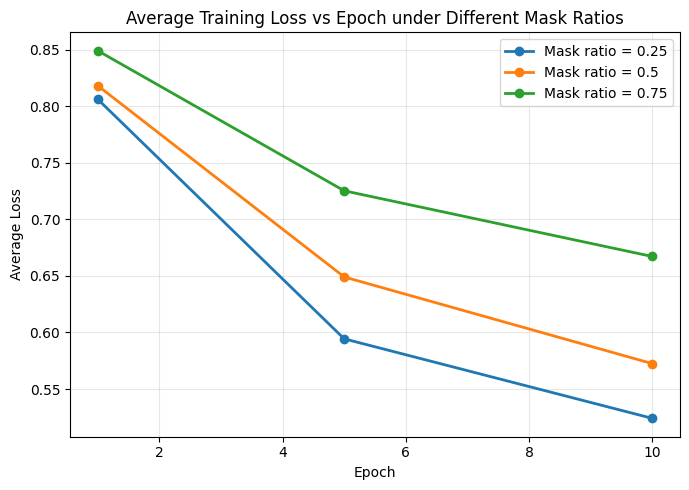

Mask ratio 0.25:
  Epoch 1 final loss = 0.5920
  Epoch 10 final loss = 0.4583
  Change = -0.1337

Mask ratio 0.5:
  Epoch 1 final loss = 0.5943
  Epoch 10 final loss = 0.5224
  Change = -0.0719

Mask ratio 0.75:
  Epoch 1 final loss = 0.6225
  Epoch 10 final loss = 0.6614
  Change = 0.0389

Saved files:
 - final_loss_vs_mask_ratio_epoch10.png
 - avg_loss_vs_epoch.png
 - summary1.csv
 - loss_vs_epoch.png
 - final_loss_table.csv


In [8]:

# Mask Ratio Analysis


import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Go to project root
# %cd /content/CS543_Reproducing_and_Analyzing_SimMIM

# 2. Read result CSV
csv_path = "../outputs/multi_epoch_results.csv"
df = pd.read_csv(csv_path)

# 3. Basic check
print("Data shape:", df.shape)
display(df)

# 4. Keep useful columns
summary_df = df[
    [
        "mask_ratio",
        "epochs",
        "final_loss",
        "avg_loss",
        "num_loss_values",
        "training_time_min",
    ]
].copy()

summary_df = summary_df.sort_values(["mask_ratio", "epochs"])
display(summary_df)

# 5. Make paper-style pivot table
loss_table = summary_df.pivot(
    index="mask_ratio",
    columns="epochs",
    values="final_loss"
)

loss_table = loss_table.rename_axis("Mask Ratio").rename_axis("Epochs", axis=1)

print("Final loss table:")
display(loss_table)

# 6. Save table
os.makedirs("../outputs/analysis", exist_ok=True)


loss_table.to_csv("../outputs/analysis/final_loss_table.csv")
summary_df.to_csv("../outputs/analysis/summary1.csv", index=False)

# Training Loss vs Epoch


plt.figure(figsize=(7, 5))

for ratio in sorted(summary_df["mask_ratio"].unique()):
    subset = summary_df[summary_df["mask_ratio"] == ratio]
    plt.plot(
        subset["epochs"],
        subset["final_loss"],
        marker="o",
        linewidth=2,
        label=f"Mask ratio = {ratio}"
    )

plt.xlabel("Epoch")
plt.ylabel("Final Loss")
plt.title("Training Loss vs Epoch under Different Mask Ratios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../outputs/analysis/loss_vs_epoch.png", dpi=300)
plt.show()


# Final Loss vs Mask Ratio at Epoch 10


epoch_to_compare = 10
final_epoch_df = summary_df[summary_df["epochs"] == epoch_to_compare].copy()

plt.figure(figsize=(7, 5))

plt.plot(
    final_epoch_df["mask_ratio"],
    final_epoch_df["final_loss"],
    marker="o",
    linewidth=2
)

plt.xlabel("Mask Ratio")
plt.ylabel("Final Loss")
plt.title(f"Final Loss vs Mask Ratio at Epoch {epoch_to_compare}")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../outputs/analysis/final_loss_vs_mask_ratio_epoch10.png", dpi=300)
plt.show()

display(final_epoch_df)


# Average Loss vs Epoch


plt.figure(figsize=(7, 5))

for ratio in sorted(summary_df["mask_ratio"].unique()):
    subset = summary_df[summary_df["mask_ratio"] == ratio]
    plt.plot(
        subset["epochs"],
        subset["avg_loss"],
        marker="o",
        linewidth=2,
        label=f"Mask ratio = {ratio}"
    )

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Average Training Loss vs Epoch under Different Mask Ratios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../outputs/analysis/avg_loss_vs_epoch.png", dpi=300)
plt.show()


# 7. Generate simple text summary for report


for ratio in sorted(summary_df["mask_ratio"].unique()):
    subset = summary_df[summary_df["mask_ratio"] == ratio].sort_values("epochs")
    first_loss = subset.iloc[0]["final_loss"]
    last_loss = subset.iloc[-1]["final_loss"]
    change = last_loss - first_loss

    print(f"Mask ratio {ratio}:")
    print(f"  Epoch {int(subset.iloc[0]['epochs'])} final loss = {first_loss:.4f}")
    print(f"  Epoch {int(subset.iloc[-1]['epochs'])} final loss = {last_loss:.4f}")
    print(f"  Change = {change:.4f}")
    print()



print("Saved files:")
for file in os.listdir("../outputs/analysis"):
    print(" -", file)